# 03 BMRA

Run BMRA based on global responses derived from the pathway activity predictions.

In [1]:
import pandas as pd
import numpy as np
import os
import bmra

In [2]:
cell_line = 'BC3C'

data_dir =f'/home/jing/Phd_project/project_UCD_blca/blca_publication_OUTPUT/blca_publication_OUTPUT_bmra/blca_publication_OUTPUT_bmra_{cell_line}/'
data_dir_1 = os.path.join(data_dir, f'00_outputs_2020_{cell_line}/')
data_dir_2 = os.path.join(data_dir, f'01_outputs_2020_{cell_line}/')

info_dir =f"/home/jing/Phd_project/project_UCD_blca/blca_publication_OUTPUT/blca_publication_OUTPUT_LINCS/00_outputs_2020_{cell_line}/"

out_dir = os.path.join(data_dir,f'02_outputs_2020_{cell_line}/')


os.makedirs(out_dir, exist_ok = True)

## Load data

### Global responses

Assembled from global responses calculated from predicted pathway activities, and DPD global responses.

In [3]:
def assemble_R_global(pathway_rglobal_file, dpd_rglobal_file):
    """
    Assemble full R_global matrix
    """
    R_global_modules_df = pd.read_csv(pathway_rglobal_file, index_col = 0)

    perts = R_global_modules_df.columns.tolist()

    R_global_DPD_df = pd.read_csv(dpd_rglobal_file, index_col=0).T

    # filter by perts list
    R_global_DPD_df = R_global_DPD_df[R_global_DPD_df.index.isin(perts)]

    # sort by perts list
    R_global_DPD_df["sort_col"] = R_global_DPD_df.index.map({val: i for i, val in enumerate(perts)})
    R_global_DPD_df = R_global_DPD_df.sort_values("sort_col")
    R_global_DPD_df = R_global_DPD_df.drop("sort_col", axis = 1)

    # transpose
    R_global_DPD_df = R_global_DPD_df.T

    R_global_df = pd.concat([R_global_modules_df, R_global_DPD_df])

    return R_global_df

In [4]:
R_global_df = assemble_R_global(
    pathway_rglobal_file = os.path.join(data_dir_2, "R_global_annotated.csv"),
    dpd_rglobal_file = os.path.join(data_dir_1, "R_global_DPDonly_annotated.csv"),
)

modules = R_global_df.index.tolist()
exp_ids = R_global_df.columns.tolist()

R_global = R_global_df.values
n_modules = R_global.shape[0]

print(R_global.shape)
display(R_global_df)

(12, 86)


,ASG002_BC3C_24H:A10,ASG002_BC3C_24H:A11,ASG002_BC3C_24H:A19,ASG002_BC3C_24H:A20,ASG002_BC3C_24H:A21,ASG002_BC3C_24H:B10,ASG002_BC3C_24H:B11,ASG002_BC3C_24H:B14,ASG002_BC3C_24H:B15,ASG002_BC3C_24H:C13,...,MOAR010_BC3C_24H:A15,MOAR010_BC3C_24H:J22,MOAR010_BC3C_24H:J23,MOAR010_BC3C_24H:J24,MOAR010_BC3C_24H:K07,MOAR010_BC3C_24H:K08,MOAR010_BC3C_24H:K09,MOAR011_BC3C_24H:F07,MOAR011_BC3C_24H:F08,MOAR011_BC3C_24H:F09
CDK1_2,-0.820160,-0.642862,0.065362,-0.087737,0.093715,-0.286267,0.001931,-0.276689,0.119766,0.047070,...,0.064573,0.059483,-0.001462,-0.229014,-0.221563,-0.101776,-0.009756,-0.845880,0.105543,-0.064859
CDK4_6,-0.024899,-0.234373,-0.042053,-0.515399,0.040071,0.002284,-0.007493,0.097552,0.085928,0.031881,...,-0.026570,-0.082978,0.190277,-0.098058,0.468754,0.097383,0.188448,0.318053,0.198911,-0.063431
EGFR,0.593692,0.494285,0.227224,0.364974,0.488497,0.111969,-0.411703,0.262709,0.284063,-0.047412,...,-0.337399,-0.257564,-0.179870,-0.336364,0.145640,-0.044827,0.178441,-0.445349,-0.553711,-0.313522
Estrogen,-0.127860,-0.214846,-0.213716,-0.410911,-0.953006,-0.307857,-0.087312,-0.243954,-0.168179,-0.042541,...,0.040748,0.136420,-0.120636,-0.103847,0.133259,-0.113612,0.108379,-1.526867,-0.225656,0.184068
FGFR,-0.105079,-0.188275,-0.088864,0.053075,-0.031325,-0.400487,-0.025607,-0.059265,-0.071358,-0.285025,...,0.178922,0.199166,0.230097,-0.858495,-0.763273,-0.646301,0.266080,-0.530704,0.053557,0.236427
PI3K,-1.925800,-1.735676,-1.502875,-1.303517,-0.688591,-0.194374,-0.028099,-0.490470,-1.181865,-0.218666,...,0.545062,-0.046428,0.152776,0.440799,-0.262550,0.225010,-0.224851,-1.082295,0.362620,-0.038495
p53,-0.269218,-0.266613,-0.164467,-0.410371,0.029057,-1.627852,-1.476743,-0.114234,-0.095967,-1.327216,...,-0.151053,-0.118611,-0.161732,-0.080834,-1.825272,-1.507098,-1.787053,-0.221455,-0.050382,0.031325
TOP2A,-0.222953,0.075958,-0.231133,-0.172164,-0.125739,0.051805,0.068254,-1.956769,-0.204447,-0.289599,...,-0.036545,-0.198105,-0.195023,-0.016458,-0.145712,0.236897,0.169416,-0.744470,-0.008686,-0.030539
Src,-0.925197,-1.670718,0.525593,-1.210373,0.573652,-1.121370,0.496075,0.399822,0.397925,0.449145,...,0.158544,0.147088,0.013150,0.038902,0.185428,0.314120,0.080716,0.034128,0.242683,0.776194
SMAD3,-0.000005,0.000150,0.000287,0.000293,0.000073,0.000340,0.000037,0.000125,0.000200,0.000251,...,-0.006421,-0.000401,0.000287,-0.000014,0.000092,0.000072,0.000239,0.000294,0.000265,0.000555


In [5]:
print(R_global_df.values.min())
print(R_global_df.values.max())

-1.998420601916184
1.266216428290639


### Perturbation matrix

In [6]:
inhib_conc_df = pd.read_csv(os.path.join(data_dir_1, "inhib_conc_annotated.csv"), index_col = 0)
#LFC_PLCg = pd.read_csv(os.path.join(info_dir,"PLCg_Data_log_2020.csv"),index_col=0)
#inhib_conc = inhib_conc_df.drop(columns=LFC_PLCg.index).values
inhib_conc = inhib_conc_df.values

n_DPDs = R_global.shape[0] - inhib_conc.shape[0]

pert_modules = np.where(inhib_conc != 0, 1, 0)
pert_DPD = np.zeros((n_DPDs, len(exp_ids)))

pert = np.vstack([pert_modules, pert_DPD])

print(pert.shape)
print(pert)

(12, 86)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


### Networks

In [15]:
# empty prior
#G_prior = np.zeros((n_modules, n_modules))
G_prior_df = pd.read_excel('/home/jing/Phd_project/project_UCD_blca/blca_DATA/blca_DATA_finalisation/prior_network.xlsx', index_col = 0)

G_prior = G_prior_df.values
G_prior_df

,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_immuno
CDK1_2,0,0,0,0,0,0,0,0,0,0,0,0
CDK4_6,0,0,0,0,0,0,0,0,0,0,0,0
EGFR,0,0,0,0,0,0,0,0,0,0,0,0
Estrogen,0,0,0,0,0,0,0,0,0,0,0,0
FGFR,0,0,0,0,0,0,0,0,0,0,0,0
PI3K,0,0,0,0,0,0,0,0,0,0,0,0
p53,0,0,0,0,0,0,0,0,0,0,0,0
TOP2A,0,0,0,0,0,0,0,0,0,0,0,0
Src,0,0,0,0,0,0,0,0,0,0,0,0
SMAD3,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
#G_prior_r_df = pd.read_excel(os.path.join(info_dir, "ALL_DATA_2020.xlsx"), sheet_name = "prior_r", index_col = 0)

#G_prior_r = G_prior_r_df.values
#G_prior_r_df

In [16]:
G_not = np.eye(n_modules)
G_not[:, n_modules - n_DPDs :] = 1

G_not

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.]])

## Run BMRA

In [17]:
n_gibbs = 200_000
n_window = 5_000

mode = "all"
n_iterations = 1

In [19]:
A_mean, A_sd, r_mean, r_sd = bmra.run_bmra(R_global,
            pert,
            G_prior,
            G_not,
            #r_prior = G_prior_r,
            n_gibbs = n_gibbs,
            n_window = n_window,
            mode = mode,
            n_iterations = n_iterations,
        )

A_mean_df = pd.DataFrame(A_mean, index = modules, columns = modules)
A_sd_df = pd.DataFrame(A_sd, index = modules, columns = modules)
r_mean_df = pd.DataFrame(r_mean, index = modules, columns = modules)
r_sd_df = pd.DataFrame(r_sd, index = modules, columns = modules)

display(A_mean_df)
display(A_sd_df)
display(r_mean_df)
display(r_sd_df)

A_mean_df.to_csv(os.path.join(out_dir, "A_mean.csv"))
A_sd_df.to_csv(os.path.join(out_dir, "A_sd.csv"))
r_mean_df.to_csv(os.path.join(out_dir, "r_mean.csv"))
r_sd_df.to_csv(os.path.join(out_dir, "r_sd.csv"))

,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_immuno_0
CDK1_2,0.000000,0.054930,0.432160,0.000000,0.853076,1.000000,0.001510,0.000000,0.588418,0.0,0.0,0.0
CDK4_6,0.000000,0.000000,1.000000,0.000000,0.000000,0.147811,0.000000,0.000000,1.000000,0.0,0.0,0.0
EGFR,0.000000,0.003979,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Estrogen,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.271353,0.0,0.0,0.0
FGFR,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.039857,0.000000,0.000000,0.0,0.0,0.0
PI3K,1.000000,0.000000,1.000000,0.002271,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.0,0.0
p53,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
TOP2A,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.002078,0.540956,0.364488,1.000000,0.000000,0.002078,0.000000,0.000000,0.000000,0.0,0.0,0.0
SMAD3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_immuno_0
CDK1_2,0.000000e+00,0.227844,4.953764e-01,0.000000e+00,3.540304e-01,6.661338e-16,3.883284e-02,0.000000e+00,4.921202e-01,0.0,0.0,0.0
CDK4_6,0.000000e+00,0.000000,7.771561e-16,0.000000e+00,0.000000e+00,3.549122e-01,0.000000e+00,0.000000e+00,7.771561e-16,0.0,0.0,0.0
EGFR,0.000000e+00,0.062956,0.000000e+00,0.000000e+00,1.332268e-15,1.332268e-15,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0
Estrogen,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,1.332268e-15,1.332268e-15,0.000000e+00,0.000000e+00,4.446580e-01,0.0,0.0,0.0
FGFR,0.000000e+00,0.000000,2.220446e-15,0.000000e+00,0.000000e+00,2.220446e-15,1.956240e-01,0.000000e+00,0.000000e+00,0.0,0.0,0.0
PI3K,1.998401e-15,0.000000,1.998401e-15,4.760103e-02,0.000000e+00,0.000000e+00,0.000000e+00,1.998401e-15,0.000000e+00,0.0,0.0,0.0
p53,0.000000e+00,0.000000,2.220446e-16,0.000000e+00,0.000000e+00,2.220446e-16,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0
TOP2A,0.000000e+00,0.000000,3.330669e-16,0.000000e+00,0.000000e+00,3.330669e-16,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0
Src,4.553302e-02,0.498320,4.812864e-01,2.442491e-15,0.000000e+00,4.553302e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0
SMAD3,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_immuno_0
CDK1_2,0.000000,0.008782,0.070931,0.000000,0.210859,0.152633,0.000076,0.000000,0.057716,0.0,0.0,0.0
CDK4_6,0.000000,0.000000,0.293111,0.000000,0.000000,0.013871,0.000000,0.000000,0.102419,0.0,0.0,0.0
EGFR,0.000000,0.000790,0.000000,0.000000,0.270868,-0.261738,0.000000,0.000000,0.000000,0.0,0.0,0.0
Estrogen,0.000000,0.000000,0.000000,0.000000,0.272529,0.173329,0.000000,0.000000,0.023576,0.0,0.0,0.0
FGFR,0.000000,0.000000,0.404120,0.000000,0.000000,0.174904,0.004216,0.000000,0.000000,0.0,0.0,0.0
PI3K,0.401544,0.000000,-0.224481,0.000442,0.000000,0.000000,0.000000,0.614586,0.000000,0.0,0.0,0.0
p53,0.000000,0.000000,0.224198,0.000000,0.000000,0.243009,0.000000,0.000000,0.000000,0.0,0.0,0.0
TOP2A,0.000000,0.000000,-0.127390,0.000000,0.000000,0.193592,0.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.000767,0.207944,0.091278,0.510591,0.000000,-0.000563,0.000000,0.000000,0.000000,0.0,0.0,0.0
SMAD3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_immuno_0
CDK1_2,0.000000,0.037667,0.087518,0.000000,0.102417,0.045469,0.002042,0.000000,0.053291,0.0,0.0,0.0
CDK4_6,0.000000,0.000000,0.028598,0.000000,0.000000,0.034953,0.000000,0.000000,0.018874,0.0,0.0,0.0
EGFR,0.000000,0.012518,0.000000,0.000000,0.025831,0.013861,0.000000,0.000000,0.000000,0.0,0.0,0.0
Estrogen,0.000000,0.000000,0.000000,0.000000,0.027713,0.012829,0.000000,0.000000,0.040148,0.0,0.0,0.0
FGFR,0.000000,0.000000,0.014802,0.000000,0.000000,0.012868,0.020949,0.000000,0.000000,0.0,0.0,0.0
PI3K,0.036348,0.000000,0.030397,0.009296,0.000000,0.000000,0.000000,0.043424,0.000000,0.0,0.0,0.0
p53,0.000000,0.000000,0.035478,0.000000,0.000000,0.031631,0.000000,0.000000,0.000000,0.0,0.0,0.0
TOP2A,0.000000,0.000000,0.024009,0.000000,0.000000,0.023569,0.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.016834,0.197667,0.123667,0.068631,0.000000,0.012364,0.000000,0.000000,0.000000,0.0,0.0,0.0
SMAD3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0


In [20]:
np.fill_diagonal(r_mean_df.values,-1)
rm_minus_inv = pd.DataFrame(np.linalg.pinv(r_mean_df),index=r_mean_df.index,columns=r_mean_df.columns)*(-1)
rm_minus_inv.to_csv(os.path.join(out_dir, 'r_minv.csv'))
display(rm_minus_inv)

,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_immuno_0
CDK1_2,1.083845e+00,2.329631e-02,1.379676e-01,3.365587e-02,2.750821e-01,2.086823e-01,1.241781e-03,1.282533e-01,6.573496e-02,-3.888085e-17,2.151057e-16,-1.457168e-16
CDK4_6,-2.669143e-02,1.021761e+00,3.716888e-01,5.325724e-02,1.095645e-01,-6.667134e-02,4.599093e-04,-4.097528e-02,1.043628e-01,1.373955e-17,1.040834e-17,-2.671474e-16
EGFR,-1.295283e-01,-1.796424e-03,1.208296e+00,-4.102947e-03,2.988578e-01,-3.225611e-01,1.250197e-03,-1.982415e-01,-7.756608e-03,-3.517185e-17,5.481726e-16,-4.163336e-17
Estrogen,1.057449e-01,7.382970e-03,6.058277e-02,1.015847e+00,3.155550e-01,2.632871e-01,1.338398e-03,1.618126e-01,3.080880e-02,9.891718e-17,5.898060e-17,-6.938894e-18
FGFR,4.227937e-02,1.249566e-03,4.274536e-01,1.374348e-03,1.125073e+00,1.052871e-01,4.746561e-03,6.470799e-02,2.600588e-03,3.312898e-17,1.379105e-16,-2.844947e-16
PI3K,5.385522e-01,1.123884e-02,-3.523330e-01,1.725875e-02,2.282661e-02,1.341142e+00,1.369941e-04,8.242473e-01,3.264118e-02,1.520236e-17,2.775558e-17,1.110223e-16
p53,1.018329e-01,2.328382e-03,1.852770e-01,3.274154e-03,7.255027e-02,2.535918e-01,1.000314e+00,1.558540e-01,6.193077e-03,-9.562711e-17,1.353084e-16,-3.087808e-16
TOP2A,1.207602e-01,2.404601e-03,-2.221337e-01,3.863836e-03,-3.365243e-02,3.007259e-01,-1.327415e-04,1.184822e+00,7.307197e-03,8.164282e-17,2.081668e-16,1.110223e-16
Src,3.714681e-02,2.160860e-01,2.188184e-01,5.293985e-01,2.113801e-01,9.053022e-02,8.939997e-04,5.563861e-02,1.036756e+00,2.253495e-17,-2.099015e-16,8.673617e-17
SMAD3,3.343336e-17,3.136999e-18,1.085942e-17,-2.512955e-17,-3.239215e-17,1.230955e-17,5.928023e-17,-4.090006e-17,1.543359e-17,1.000000e+00,1.804591e-17,4.909691e-17


In [21]:
con_mat = pd.DataFrame(columns=['From','To','Strength'])
for con_to in r_mean_df.index:
    for con_from in r_mean_df.columns:
        if ((r_mean_df.loc[con_to,con_from] != 0) & (con_from != con_to)):
            row_df = pd.DataFrame([[con_from,con_to,r_mean_df.loc[con_to,con_from]]],columns=['From','To','Strength'])
            if con_mat.empty:
                con_mat = row_df.copy()
            else:
                con_mat = pd.concat([con_mat,row_df],axis=0,ignore_index=True)
            #con_mat = con_mat.append({'From':con_from,'To':con_to,'Strength':r_mean_df.loc[con_to,con_from]},ignore_index=True)
con_mat.to_csv(os.path.join(out_dir, 'r_net.txt'),sep='\t',index=False)
display(con_mat)

,From,To,Strength
0,CDK4_6,CDK1_2,0.008782
1,EGFR,CDK1_2,0.070931
2,FGFR,CDK1_2,0.210859
3,PI3K,CDK1_2,0.152633
4,p53,CDK1_2,0.000076
5,Src,CDK1_2,0.057716
6,EGFR,CDK4_6,0.293111
7,PI3K,CDK4_6,0.013871
8,Src,CDK4_6,0.102419
9,CDK4_6,EGFR,0.000790


In [22]:
# now the same but with filtered matrices
# threshold value
Athr = 0.5

rm_filt = r_mean_df[np.abs(A_mean_df) > Athr].fillna(0).copy()
np.fill_diagonal(rm_filt.values,-1)
rm_filt.to_csv(os.path.join(out_dir, 'r_mean_filt.csv'))
display(rm_filt)

rm_filt_minus_inv = pd.DataFrame(np.linalg.pinv(rm_filt),index=rm_filt.index,columns=rm_filt.columns)*(-1)
rm_filt_minus_inv.to_csv(os.path.join(out_dir, 'r_minv_filt.csv'))
display(rm_minus_inv)

con_mat = pd.DataFrame(columns=['From','To','Strength'])
for con_to in rm_filt.index:
    for con_from in rm_filt.columns:
        if ((rm_filt.loc[con_to,con_from] != 0) & (con_from != con_to)):
            row_df = pd.DataFrame([[con_from,con_to,rm_filt.loc[con_to,con_from]]],columns=['From','To','Strength'])
            if con_mat.empty:
                con_mat = row_df.copy()
            else:
                con_mat = pd.concat([con_mat,row_df],axis=0,ignore_index=True)
            #con_mat = con_mat.append({'From':con_from,'To':con_to,'Strength':r_mean_df.loc[con_to,con_from]},ignore_index=True)
con_mat.to_csv(os.path.join(out_dir, 'r_net_filt.txt'),sep='\t',index=False)
#display(con_mat)


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_immuno_0
CDK1_2,-1.000000,0.000000,0.000000,0.000000,0.210859,0.152633,0.000000,0.000000,0.057716,0.0,0.0,0.0
CDK4_6,0.000000,-1.000000,0.293111,0.000000,0.000000,0.000000,0.000000,0.000000,0.102419,0.0,0.0,0.0
EGFR,0.000000,0.000000,-1.000000,0.000000,0.270868,-0.261738,0.000000,0.000000,0.000000,0.0,0.0,0.0
Estrogen,0.000000,0.000000,0.000000,-1.000000,0.272529,0.173329,0.000000,0.000000,0.000000,0.0,0.0,0.0
FGFR,0.000000,0.000000,0.404120,0.000000,-1.000000,0.174904,0.000000,0.000000,0.000000,0.0,0.0,0.0
PI3K,0.401544,0.000000,-0.224481,0.000000,0.000000,-1.000000,0.000000,0.614586,0.000000,0.0,0.0,0.0
p53,0.000000,0.000000,0.224198,0.000000,0.000000,0.243009,-1.000000,0.000000,0.000000,0.0,0.0,0.0
TOP2A,0.000000,0.000000,-0.127390,0.000000,0.000000,0.193592,0.000000,-1.000000,0.000000,0.0,0.0,0.0
Src,0.000000,0.207944,0.000000,0.510591,0.000000,0.000000,0.000000,0.000000,-1.000000,0.0,0.0,0.0
SMAD3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0,0.0,0.0


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_immuno_0
CDK1_2,1.083845e+00,2.329631e-02,1.379676e-01,3.365587e-02,2.750821e-01,2.086823e-01,1.241781e-03,1.282533e-01,6.573496e-02,-3.888085e-17,2.151057e-16,-1.457168e-16
CDK4_6,-2.669143e-02,1.021761e+00,3.716888e-01,5.325724e-02,1.095645e-01,-6.667134e-02,4.599093e-04,-4.097528e-02,1.043628e-01,1.373955e-17,1.040834e-17,-2.671474e-16
EGFR,-1.295283e-01,-1.796424e-03,1.208296e+00,-4.102947e-03,2.988578e-01,-3.225611e-01,1.250197e-03,-1.982415e-01,-7.756608e-03,-3.517185e-17,5.481726e-16,-4.163336e-17
Estrogen,1.057449e-01,7.382970e-03,6.058277e-02,1.015847e+00,3.155550e-01,2.632871e-01,1.338398e-03,1.618126e-01,3.080880e-02,9.891718e-17,5.898060e-17,-6.938894e-18
FGFR,4.227937e-02,1.249566e-03,4.274536e-01,1.374348e-03,1.125073e+00,1.052871e-01,4.746561e-03,6.470799e-02,2.600588e-03,3.312898e-17,1.379105e-16,-2.844947e-16
PI3K,5.385522e-01,1.123884e-02,-3.523330e-01,1.725875e-02,2.282661e-02,1.341142e+00,1.369941e-04,8.242473e-01,3.264118e-02,1.520236e-17,2.775558e-17,1.110223e-16
p53,1.018329e-01,2.328382e-03,1.852770e-01,3.274154e-03,7.255027e-02,2.535918e-01,1.000314e+00,1.558540e-01,6.193077e-03,-9.562711e-17,1.353084e-16,-3.087808e-16
TOP2A,1.207602e-01,2.404601e-03,-2.221337e-01,3.863836e-03,-3.365243e-02,3.007259e-01,-1.327415e-04,1.184822e+00,7.307197e-03,8.164282e-17,2.081668e-16,1.110223e-16
Src,3.714681e-02,2.160860e-01,2.188184e-01,5.293985e-01,2.113801e-01,9.053022e-02,8.939997e-04,5.563861e-02,1.036756e+00,2.253495e-17,-2.099015e-16,8.673617e-17
SMAD3,3.343336e-17,3.136999e-18,1.085942e-17,-2.512955e-17,-3.239215e-17,1.230955e-17,5.928023e-17,-4.090006e-17,1.543359e-17,1.000000e+00,1.804591e-17,4.909691e-17


In [23]:
# number of zero elements in the matrix
display(len(rm_filt.index)*len(rm_filt.columns) - rm_filt.astype(bool).sum().sum())

105

In [24]:
# number of non-zero elements in the matrix
display(rm_filt.astype(bool).sum().sum() - len(modules))

27

### Visualization

In [26]:
rm_filt_minus_inv

,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_immuno_0
CDK1_2,1.094633e+00,1.342339e-02,3.310957e-02,3.296017e-02,2.487646e-01,2.356742e-01,-3.504141e-16,1.448421e-01,6.455296e-02,1.583088e-18,-3.538836e-16,4.024558e-16
CDK4_6,-3.355750e-02,1.021349e+00,3.678521e-01,5.242176e-02,1.068498e-01,-8.357123e-02,-6.383782e-16,-5.136171e-02,1.026688e-01,2.784840e-17,6.487866e-16,3.712308e-16
EGFR,-1.309212e-01,-1.605475e-03,1.220227e+00,-3.942129e-03,3.018396e-01,-3.260448e-01,-0.000000e+00,-2.003826e-01,-7.720715e-03,-3.837865e-18,-1.387779e-17,-3.747003e-16
Estrogen,1.057794e-01,1.297163e-03,4.505058e-02,1.003185e+00,3.079044e-01,2.634318e-01,-1.075529e-16,1.619015e-01,6.238044e-03,2.975775e-17,8.049117e-16,1.526557e-16
FGFR,4.222156e-02,5.177590e-04,4.224126e-01,1.271320e-03,1.123667e+00,1.051481e-01,-5.017688e-16,6.462256e-02,2.489899e-03,-1.986378e-18,3.148523e-16,-2.289835e-16
PI3K,5.438947e-01,6.669730e-03,-4.042549e-01,1.637705e-02,9.648901e-03,1.354510e+00,-1.734723e-16,8.324626e-01,3.207468e-02,1.374353e-18,7.771561e-16,1.942890e-16
p53,1.028189e-01,1.260859e-03,1.753345e-01,3.095948e-03,7.001650e-02,2.560591e-01,1.000000e+00,1.573703e-01,6.063459e-03,-2.068829e-17,-9.020562e-16,-2.532696e-16
TOP2A,1.219719e-01,1.495730e-03,-2.337053e-01,3.672659e-03,-3.658339e-02,3.037575e-01,-3.712308e-16,1.186685e+00,7.192954e-03,6.260305e-18,1.554312e-15,1.249001e-16
Src,4.703194e-02,2.130456e-01,9.949499e-02,5.231182e-01,1.794320e-01,1.171278e-01,-1.491862e-16,7.198513e-02,1.024534e+00,2.994302e-17,2.081668e-16,1.040834e-17
SMAD3,3.000101e-17,2.273456e-16,7.201741e-17,-8.970240e-18,-1.113691e-16,2.174163e-17,1.107842e-16,-6.139273e-18,6.523817e-17,1.000000e+00,1.359835e-16,-1.472766e-16


In [27]:
df_subset=rm_filt_minus_inv[[ 'CDK1_2', 'CDK4_6', 'EGFR', 'Estrogen', 'FGFR',
       'p53','PI3K',  'TOP2A','Src']]
df_subset = df_subset.loc[['DPD_onc',	'DPD_immuno_0']]

In [28]:
t_df_subset=df_subset.T
df_subset.reset_index(inplace=True)

Text(0.5, 1.0, 'Predicted global signaling pathway responses of BC3C cell line under conditions ')

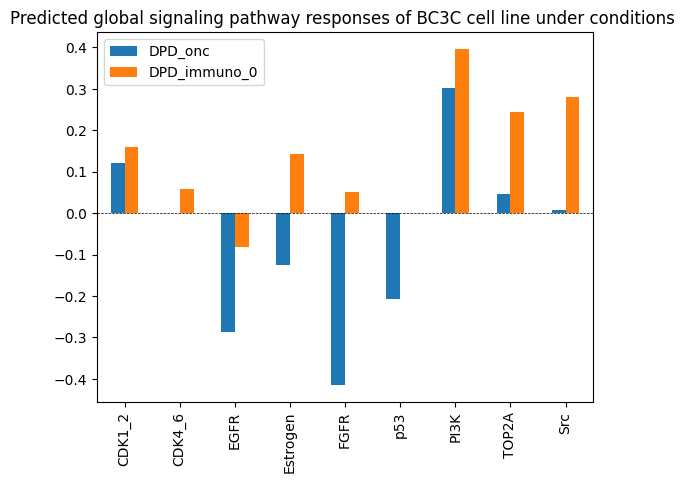

In [29]:
import matplotlib.pyplot as plt
t_df_subset.plot.bar()
plt.axhline(y=0, linestyle='--', color='black',linewidth=0.5)
plt.title(f"Predicted global signaling pathway responses of {cell_line} cell line under conditions ")

In [30]:
display(rm_filt)
rm_subset=rm_filt[['CDK1_2', 'CDK4_6', 'EGFR', 'Estrogen', 'FGFR',
       'PI3K', 'p53', 'TOP2A','Src']]

,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_immuno_0
CDK1_2,-1.000000,0.000000,0.000000,0.000000,0.210859,0.152633,0.000000,0.000000,0.057716,0.0,0.0,0.0
CDK4_6,0.000000,-1.000000,0.293111,0.000000,0.000000,0.000000,0.000000,0.000000,0.102419,0.0,0.0,0.0
EGFR,0.000000,0.000000,-1.000000,0.000000,0.270868,-0.261738,0.000000,0.000000,0.000000,0.0,0.0,0.0
Estrogen,0.000000,0.000000,0.000000,-1.000000,0.272529,0.173329,0.000000,0.000000,0.000000,0.0,0.0,0.0
FGFR,0.000000,0.000000,0.404120,0.000000,-1.000000,0.174904,0.000000,0.000000,0.000000,0.0,0.0,0.0
PI3K,0.401544,0.000000,-0.224481,0.000000,0.000000,-1.000000,0.000000,0.614586,0.000000,0.0,0.0,0.0
p53,0.000000,0.000000,0.224198,0.000000,0.000000,0.243009,-1.000000,0.000000,0.000000,0.0,0.0,0.0
TOP2A,0.000000,0.000000,-0.127390,0.000000,0.000000,0.193592,0.000000,-1.000000,0.000000,0.0,0.0,0.0
Src,0.000000,0.207944,0.000000,0.510591,0.000000,0.000000,0.000000,0.000000,-1.000000,0.0,0.0,0.0
SMAD3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0,0.0,0.0


In [31]:
rm_subset=rm_subset.loc[['DPD_onc',	'DPD_immuno_0']]
rm_subset=rm_subset.T
display(rm_subset)

,DPD_onc,DPD_immuno_0
CDK1_2,0.000000,0.000000
CDK4_6,0.000000,0.000000
EGFR,0.000000,0.000000
Estrogen,-0.128297,0.000000
FGFR,-0.328406,0.000000
PI3K,0.344188,0.269758
p53,-0.207112,0.000000
TOP2A,-0.138955,0.000000
Src,0.000000,0.264514


Text(0.5, 1.0, 'Predicted local signaling pathway responses of BC3C cell line under conditions ')

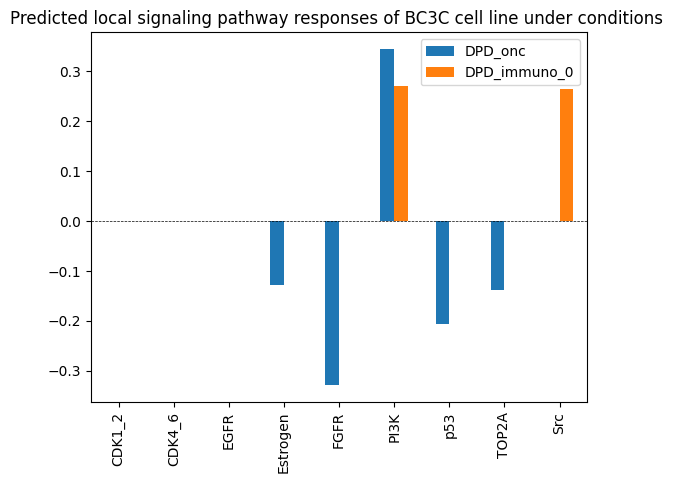

In [32]:
rm_subset.plot.bar()
plt.axhline(y=0, linestyle='--', color='black',linewidth=0.5)
plt.title(f"Predicted local signaling pathway responses of {cell_line} cell line under conditions ")